In [1]:
import logging
from argparse import ArgumentParser
from multiprocessing import Pool
from pathlib import Path
from random import shuffle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
from laptrack import LapTrack
from skimage.measure import regionprops_table
from skimage.transform import downscale_local_mean
import itertools
from typing import Iterable, List, Any
from tqdm import tqdm

def chunker(iterable: Iterable[Any], size: int) -> Iterable[List[Any]]:
    """
    Batch data into lists of length n. The last batch may be shorter.
    """
    it = iter(iterable)
    while True:
        chunk = list(itertools.islice(it, size))
        if not chunk:
            break
        yield chunk

logging.basicConfig(level="INFO")



C:\Users\Nikon\Desktop\Code\Toettchlab-FBC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:


def run_cellpose(infile, args):
    from cellpose import models
    from cellpose.io import imread

    model = models.CellposeModel(gpu=True, pretrained_model=args.model)

    stack = imread(infile)

    stack = [frame.astype(np.uint16)[args.channel] for frame in stack]

    if len(args.cellpose_norm) == 2:
        normalize = {"lowhigh": [args.cellpose_norm[0], args.cellpose_norm[1]]}

    else:
        normalize = True

    all_masks = []

    for substack in tqdm(chunker(stack, 2)):
        height = substack[0].shape[0]
        long_img = np.concatenate(substack, axis=0)

        masks, _flows, _styles = model.eval(long_img, batch_size=64, normalize=normalize)

        for i in range(0, masks.shape[0], height):
            this_masks = masks[i:i+height]
            all_masks.append(this_masks)

    masks = np.stack(all_masks, axis=0)

    return masks


def process_masks(masks):
    collect_spots = []

    for t, frame in enumerate(masks):
        props = regionprops_table(frame, properties=["label", "area", "centroid"])

        df = pd.DataFrame(props)
        df["frame"] = t
        df = df.rename(columns={"centroid-0": "px_y", "centroid-1": "px_x"})

        print(df)

        collect_spots.append(df)

    spots_df = pd.concat([s for s in collect_spots], ignore_index=True)

    return spots_df


def track_spots(spots_df):
    max_distance = 20

    lt = LapTrack(
        metric="sqeuclidean",
        # The similarity metric for particles. See `scipy.spatial.distance.cdist` for allowed values.
        splitting_metric="sqeuclidean",
        merging_metric="sqeuclidean",
        gap_closing_metric="sqeuclidean",
        # the square of the cutoff distance for the "sqeuclidean" metric
        cutoff=max_distance**2,
        splitting_cutoff=False,  # or False for non-splitting case
        merging_cutoff=False,  # or False for non-merging case
        gap_closing_cutoff=max_distance**2,
        gap_closing_max_frame_count=2,
    )

    track_df, _split_df, _merge_df = lt.predict_dataframe(
        spots_df,
        coordinate_cols=[
            "px_x",
            "px_y",
        ],  # the column names for the coordinates
        frame_col="frame",  # the column name for the frame (default "frame")
        only_coordinate_cols=False,
    )

    track_df = track_df.rename(columns={"frame_y": "frame"})

    return track_df

def process_file(infile, in_dir, args):
    masks_dir = in_dir / "masks"
    tracks_dir = in_dir / "tracks"

    masks_outfile = masks_dir / f"{infile.stem}_masks.tif"
    tracks_outfile = tracks_dir / f"{infile.stem}_tracks.csv"

    print(masks_outfile)

    if masks_outfile.exists():
        cellpose_masks = tifffile.imread(masks_outfile)
        print(f"{masks_outfile.stem} exists: loading data")

    else:
        cellpose_masks = run_cellpose(str(infile), args)
        tifffile.imwrite(
            masks_outfile,
            cellpose_masks.astype(np.uint16),
            imagej=True,
            metadata={"axes": "tyx"},
        )

    if tracks_outfile.exists():
        tracks = pd.read_csv(tracks_outfile)
        print(f"{tracks_outfile.stem} exists: loading data")

    else:
        spots = process_masks(cellpose_masks)

        tracks = track_spots(spots)
        tracks.to_csv(tracks_outfile, index=False)

    return tracks

In [3]:
from types import SimpleNamespace

args = SimpleNamespace(
    dir = r"D:\Kelsey\20260224_intensity_and_duty_cycle_part2\nuclei",  # the folder containing the tifs
    glob = "*.tif",  # segments all the .tif files in a directory
    cellpose_norm = [0, 30000], # lowest and highest pixel intensities
    model = "cpsam",  # name of the cellpose model to load
    channel = 0,
)

segmenting and tracking file 0/8: dark.well1_channel_545_patterns
D:\Kelsey\20260224_intensity_and_duty_cycle_part2\nuclei\masks\dark.well1_channel_545_patterns_masks.tif


INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>>>> loading model C:\Users\Nikon\.cellpose\models\cpsam
INFO:cellpose.io:reading tiff with 120 planes
100%|██████████| 120/120 [00:00<00:00, 963.61it/s]
0it [00:00, ?it/s]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
1it [00:19, 19.99s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
2it [00:23, 10.10s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
3it [00:26,  6.92s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
4it [00:29,  5.44s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
5it [00:32,  4.59s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
6it [00:35,  4.08s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
7it [00:38,  3.73s/it]INFO:cellpose.transforms:processing grays

      label   area        px_y        px_x  frame
0         1  130.0    6.000000  109.376923      0
1         2   19.0    0.894737  131.000000      0
2         3   63.0    3.111111  225.000000      0
3         4   52.0    2.288462  279.538462      0
4         5   45.0    1.711111  309.155556      0
...     ...    ...         ...         ...    ...
1471   1472   68.0  760.602941  732.044118      0
1472   1473   70.0  762.285714  399.000000      0
1473   1474   59.0  763.050847  681.135593      0
1474   1475   37.0  766.729730  658.216216      0
1475   1476   22.0  769.636364  600.545455      0

[1476 rows x 5 columns]
      label  area        px_y        px_x  frame
0      1477  44.0    1.886364  132.113636      1
1      1478  48.0    2.937500  186.895833      1
2      1479  50.0    2.780000  198.520000      1
3      1480  89.0    4.022472  226.865169      1
4      1481  74.0    3.297297  280.972973      1
...     ...   ...         ...         ...    ...
1441   2918  59.0  760.423729  5

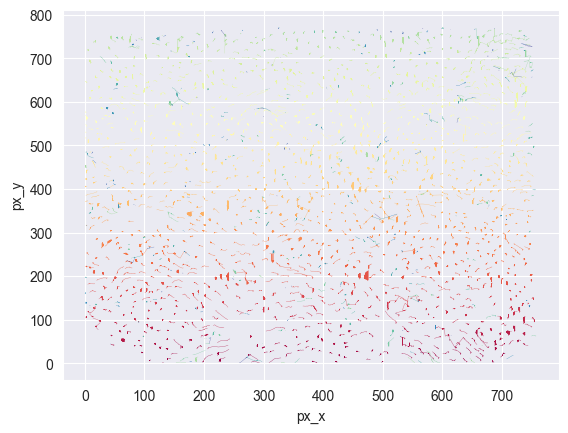

INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)


segmenting and tracking file 1/8: duty10.well4_channel_545_patterns
D:\Kelsey\20260224_intensity_and_duty_cycle_part2\nuclei\masks\duty10.well4_channel_545_patterns_masks.tif


INFO:cellpose.models:>>>> loading model C:\Users\Nikon\.cellpose\models\cpsam
INFO:cellpose.io:reading tiff with 120 planes
100%|██████████| 120/120 [00:00<00:00, 999.09it/s] 
0it [00:00, ?it/s]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
1it [00:02,  2.80s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
2it [00:05,  2.83s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
3it [00:08,  2.93s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
4it [00:11,  2.97s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
5it [00:14,  2.90s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
6it [00:17,  2.85s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
7it [00:19,  2.82s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
8it [00:22,  2.81s/it]INFO:cellpose.transforms:processing grayscale image wi

      label   area        px_y        px_x  frame
0         1   29.0    1.172414  145.241379      0
1         2   92.0    3.793478  166.097826      0
2         3   96.0    4.906250  214.114583      0
3         4   53.0    2.037736  358.037736      0
4         5  112.0    4.607143  385.178571      0
...     ...    ...         ...         ...    ...
1163   1164   80.0  766.062500  514.587500      0
1164   1165   85.0  766.776471  495.823529      0
1165   1166   59.0  767.220339  714.677966      0
1166   1167   98.0  774.234694  643.030612      0
1167   1168   75.0  774.480000  682.733333      0

[1168 rows x 5 columns]
      label   area        px_y        px_x  frame
0      1169   16.0    0.937500  120.125000      1
1      1170   50.0    1.880000  146.120000      1
2      1171  102.0    4.715686  167.254902      1
3      1172   66.0    2.666667  359.136364      1
4      1173  122.0    5.385246  386.270492      1
...     ...    ...         ...         ...    ...
1155   2324   87.0  760.3

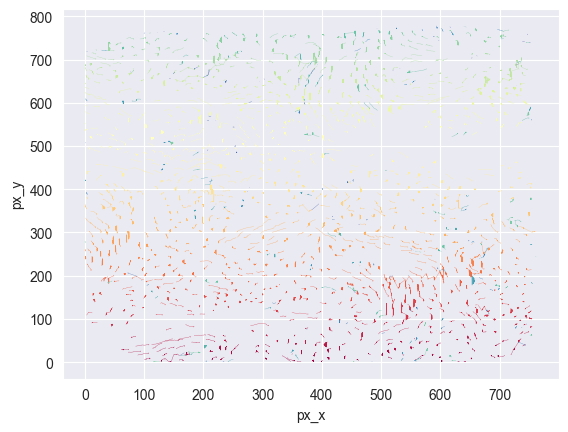

INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)


segmenting and tracking file 2/8: duty20.well5_channel_545_patterns
D:\Kelsey\20260224_intensity_and_duty_cycle_part2\nuclei\masks\duty20.well5_channel_545_patterns_masks.tif


INFO:cellpose.models:>>>> loading model C:\Users\Nikon\.cellpose\models\cpsam
INFO:cellpose.io:reading tiff with 120 planes
100%|██████████| 120/120 [00:00<00:00, 1064.25it/s]
0it [00:00, ?it/s]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
1it [00:03,  3.62s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
2it [00:07,  3.55s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
3it [00:10,  3.52s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
4it [00:14,  3.57s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
5it [00:17,  3.56s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
6it [00:21,  3.52s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
7it [00:24,  3.48s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
8it [00:27,  3.42s/it]INFO:cellpose.transforms:processing grayscale image wi

      label   area        px_y        px_x  frame
0         1   94.0    6.170213  111.946809      0
1         2   35.0    1.571429  136.028571      0
2         3   90.0    3.888889  162.766667      0
3         4   97.0    4.082474  181.494845      0
4         5  103.0    3.378641  243.563107      0
...     ...    ...         ...         ...    ...
1875   1876  108.0  754.907407  504.592593      0
1876   1877  119.0  756.327731   50.537815      0
1877   1878  107.0  757.074766  473.915888      0
1878   1879   94.0  757.053191  156.617021      0
1879   1880   57.0  758.456140  261.929825      0

[1880 rows x 5 columns]
      label   area        px_y        px_x  frame
0      1881   54.0    2.203704  137.074074      1
1      1882  102.0    4.735294  164.088235      1
2      1883  110.0    4.918182  183.154545      1
3      1884  121.0    4.132231  245.148760      1
4      1885   79.0    3.455696  326.481013      1
...     ...    ...         ...         ...    ...
1882   3763   46.0  755.1

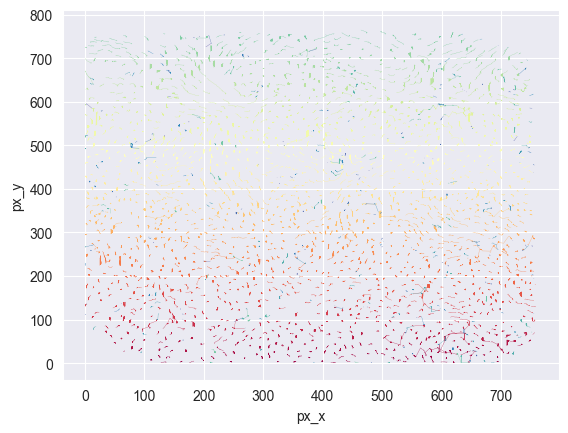

INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)


segmenting and tracking file 3/8: duty30.well5_channel_545_patterns
D:\Kelsey\20260224_intensity_and_duty_cycle_part2\nuclei\masks\duty30.well5_channel_545_patterns_masks.tif


INFO:cellpose.models:>>>> loading model C:\Users\Nikon\.cellpose\models\cpsam
INFO:cellpose.io:reading tiff with 120 planes
100%|██████████| 120/120 [00:00<00:00, 954.92it/s]
0it [00:00, ?it/s]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
1it [00:03,  3.23s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
2it [00:06,  3.42s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
3it [00:10,  3.37s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
4it [00:13,  3.31s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
5it [00:16,  3.37s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
6it [00:20,  3.37s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
7it [00:23,  3.38s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
8it [00:27,  3.67s/it]INFO:cellpose.transforms:processing grayscale image wit

      label  area        px_y        px_x  frame
0         1  21.0    0.952381  213.666667      0
1         2  98.0    3.704082  235.061224      0
2         3  71.0    4.394366  334.873239      0
3         4  36.0    1.388889  399.777778      0
4         5  21.0    0.761905  520.714286      0
...     ...   ...         ...         ...    ...
1869   1870  82.0  762.914634  520.085366      0
1870   1871  49.0  764.061224  432.632653      0
1871   1872  65.0  764.523077  472.430769      0
1872   1873  64.0  764.109375  612.468750      0
1873   1874  53.0  767.528302  729.264151      0

[1874 rows x 5 columns]
      label   area        px_y        px_x  frame
0      1875   38.0    1.605263  215.052632      1
1      1876   33.0    1.303030  267.848485      1
2      1877   21.0    1.333333  300.142857      1
3      1878   24.0    1.833333  313.958333      1
4      1879   19.0    1.000000  370.315789      1
...     ...    ...         ...         ...    ...
1866   3741  100.0  761.120000  164.6

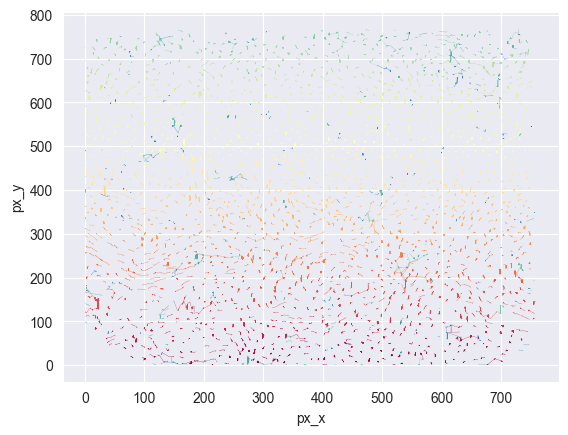

INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)


segmenting and tracking file 4/8: duty40.well5_channel_545_patterns
D:\Kelsey\20260224_intensity_and_duty_cycle_part2\nuclei\masks\duty40.well5_channel_545_patterns_masks.tif


INFO:cellpose.models:>>>> loading model C:\Users\Nikon\.cellpose\models\cpsam
INFO:cellpose.io:reading tiff with 120 planes
100%|██████████| 120/120 [00:00<00:00, 932.17it/s]
0it [00:00, ?it/s]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
1it [00:03,  3.32s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
2it [00:06,  3.33s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
3it [00:09,  3.16s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
4it [00:12,  3.12s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
5it [00:15,  3.11s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
6it [00:18,  3.05s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
7it [00:21,  3.02s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
8it [00:24,  3.00s/it]INFO:cellpose.transforms:processing grayscale image wit

      label   area        px_y        px_x  frame
0         1   25.0    1.560000  112.120000      0
1         2   27.0    1.592593  161.740741      0
2         3  106.0    5.707547  174.839623      0
3         4  105.0    5.685714  212.495238      0
4         5  235.0    7.068085  328.293617      0
...     ...    ...         ...         ...    ...
1437   1438   84.0  762.988095  420.595238      0
1438   1439   78.0  763.064103  513.641026      0
1439   1440   93.0  762.784946  695.419355      0
1440   1441   80.0  762.887500  146.137500      0
1441   1442   74.0  764.662162  663.797297      0

[1442 rows x 5 columns]
      label   area        px_y        px_x  frame
0      1443   35.0    2.114286  113.742857      1
1      1444   45.0    2.200000  163.133333      1
2      1445   22.0    1.272727  185.409091      1
3      1446  251.0    8.159363  329.717131      1
4      1447   80.0    4.262500  426.825000      1
...     ...    ...         ...         ...    ...
1430   2873   87.0  761.2

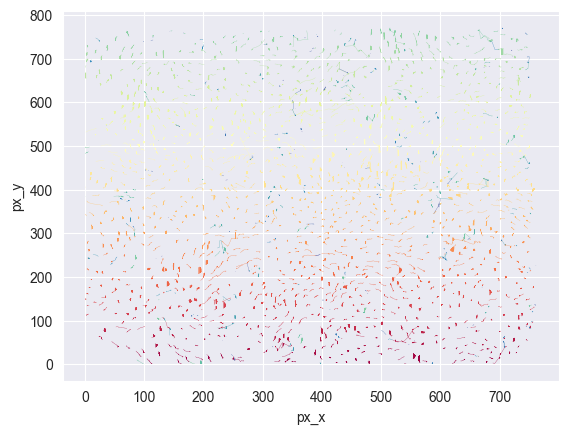

INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)


segmenting and tracking file 5/8: duty50.well5_channel_545_patterns
D:\Kelsey\20260224_intensity_and_duty_cycle_part2\nuclei\masks\duty50.well5_channel_545_patterns_masks.tif


INFO:cellpose.models:>>>> loading model C:\Users\Nikon\.cellpose\models\cpsam
INFO:cellpose.io:reading tiff with 120 planes
100%|██████████| 120/120 [00:00<00:00, 1080.16it/s]
0it [00:00, ?it/s]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
1it [00:04,  4.11s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
2it [00:08,  4.23s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
3it [00:12,  4.10s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
4it [00:16,  4.05s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
5it [00:20,  3.98s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
6it [00:23,  3.92s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
7it [00:28,  3.97s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
8it [00:31,  3.90s/it]INFO:cellpose.transforms:processing grayscale image wi

      label  area        px_y        px_x  frame
0         1  16.0    0.875000  157.500000      0
1         2  70.0    4.114286  170.271429      0
2         3  49.0    3.408163  187.244898      0
3         4  47.0    2.468085  216.680851      0
4         5  40.0    1.575000  236.375000      0
...     ...   ...         ...         ...    ...
2305   2306  69.0  760.782609  512.347826      0
2306   2307  35.0  760.800000  141.085714      0
2307   2308  69.0  762.231884  267.782609      0
2308   2309  48.0  761.687500  620.375000      0
2309   2310  46.0  765.869565  380.891304      0

[2310 rows x 5 columns]
      label  area        px_y        px_x  frame
0      2311  33.0    1.636364  158.454545      1
1      2312  17.0    1.000000  203.000000      1
2      2313  75.0    3.320000  217.960000      1
3      2314  52.0    2.076923  238.057692      1
4      2315  70.0    5.057143  283.914286      1
...     ...   ...         ...         ...    ...
2279   4590  42.0  758.833333  635.952381   

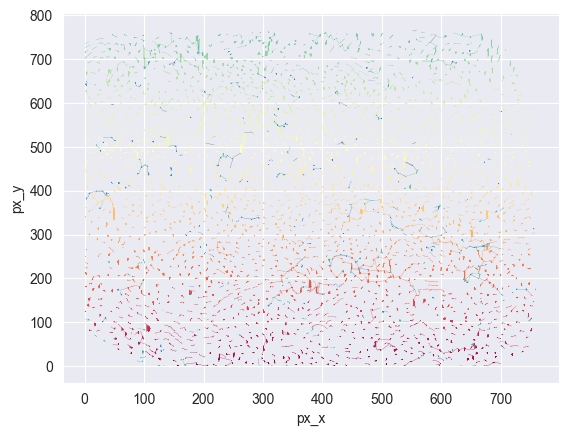

INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)


segmenting and tracking file 6/8: quadrant_gaps.well3_channel_545_patterns
D:\Kelsey\20260224_intensity_and_duty_cycle_part2\nuclei\masks\quadrant_gaps.well3_channel_545_patterns_masks.tif


INFO:cellpose.models:>>>> loading model C:\Users\Nikon\.cellpose\models\cpsam
INFO:cellpose.io:reading tiff with 120 planes
100%|██████████| 120/120 [00:00<00:00, 1061.26it/s]
0it [00:00, ?it/s]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
1it [00:02,  2.63s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
2it [00:05,  2.55s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
3it [00:07,  2.52s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
4it [00:10,  2.50s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
5it [00:12,  2.54s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
6it [00:15,  2.69s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
7it [00:18,  2.66s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
8it [00:20,  2.64s/it]INFO:cellpose.transforms:processing grayscale image wi

      label   area        px_y        px_x  frame
0         1   83.0    2.771084  215.927711      0
1         2   96.0    3.270833  394.468750      0
2         3   70.0    4.900000  476.714286      0
3         4   97.0    5.484536  506.546392      0
4         5   31.0    2.709677  635.354839      0
...     ...    ...         ...         ...    ...
1035   1036  119.0  756.008403  351.915966      0
1036   1037   83.0  757.686747  418.168675      0
1037   1038   51.0  758.117647  458.980392      0
1038   1039   48.0  765.583333  691.854167      0
1039   1040   49.0  771.918367  382.000000      0

[1040 rows x 5 columns]
      label   area        px_y        px_x  frame
0      1041   15.0    1.266667  126.666667      1
1      1042  103.0    3.388350  216.825243      1
2      1043  113.0    4.061947  396.168142      1
3      1044   92.0    5.619565  478.250000      1
4      1045  102.0    6.245098  507.764706      1
...     ...    ...         ...         ...    ...
1025   2066  121.0  751.0

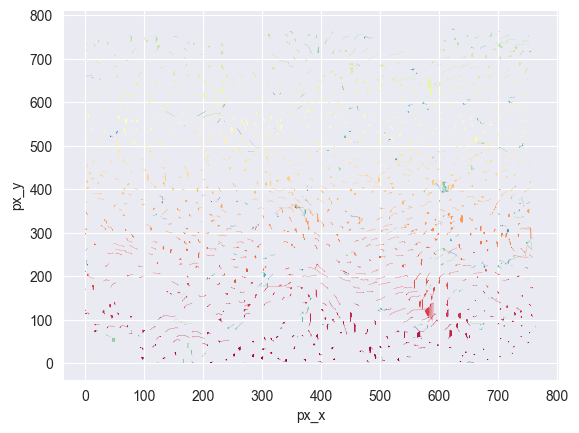

INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)


segmenting and tracking file 7/8: quadrant_nogaps.well4_channel_545_patterns
D:\Kelsey\20260224_intensity_and_duty_cycle_part2\nuclei\masks\quadrant_nogaps.well4_channel_545_patterns_masks.tif


INFO:cellpose.models:>>>> loading model C:\Users\Nikon\.cellpose\models\cpsam
INFO:cellpose.io:reading tiff with 120 planes
100%|██████████| 120/120 [00:00<00:00, 1089.84it/s]
0it [00:00, ?it/s]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
1it [00:03,  3.15s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
2it [00:05,  2.94s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
3it [00:08,  2.88s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
4it [00:11,  2.91s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
5it [00:14,  2.86s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
6it [00:17,  2.83s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
7it [00:20,  2.85s/it]INFO:cellpose.transforms:processing grayscale image with (1600, 800) HW
8it [00:22,  2.83s/it]INFO:cellpose.transforms:processing grayscale image wi

      label  area        px_y        px_x  frame
0         1  65.0    3.261538  167.846154      0
1         2  64.0    2.156250  211.953125      0
2         3  82.0    4.378049  592.207317      0
3         4  68.0    6.044118   95.117647      0
4         5  97.0    7.309278  388.680412      0
...     ...   ...         ...         ...    ...
1319   1320  79.0  760.531646  561.607595      0
1320   1321  99.0  761.535354  668.191919      0
1321   1322  41.0  760.853659  459.121951      0
1322   1323  81.0  769.160494  651.864198      0
1323   1324  81.0  770.740741  679.086420      0

[1324 rows x 5 columns]
      label   area        px_y        px_x  frame
0      1325   73.0    4.369863  168.616438      1
1      1326   84.0    3.000000  213.202381      1
2      1327   24.0    1.500000  368.000000      1
3      1328   93.0    5.645161  593.301075      1
4      1329   99.0    6.595960   96.828283      1
...     ...    ...         ...         ...    ...
1317   2642   20.0  758.750000  393.9

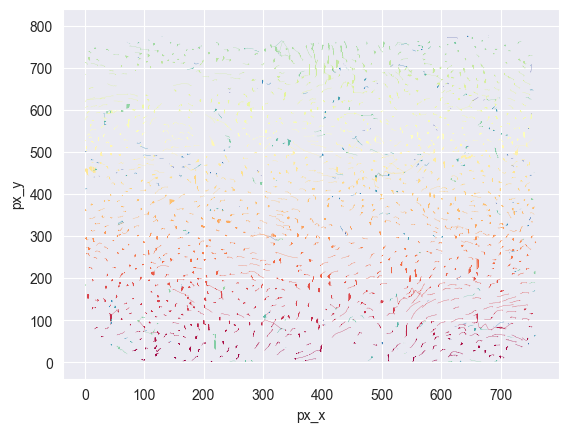

In [4]:

in_dir = Path(args.dir)

masks_dir = in_dir / "masks"
tracks_dir = in_dir / "tracks"

masks_dir.mkdir(exist_ok=True)
tracks_dir.mkdir(exist_ok=True)

files = list(in_dir.glob(args.glob))

for i, file in enumerate(files):
    print(f"segmenting and tracking file {i}/{len(files)}: {file.stem}")
    tracks = process_file(file, in_dir, args)

    import seaborn as sns

    sns.lineplot(tracks, x="px_x", y="px_y", hue="track_id", palette="Spectral", errorbar=None, lw=0.2, legend=False)
    plt.show()

